### ⚠️ Audit fix — cases_7d_avg leakage gap

`cases_7d_avg` is a raw same-day case-history column (r≈0.96-0.99 with same-day `dengue_cases`) that doesn't match any prefix in `case_pfx`, so it was leaking into the supposedly weather/calendar-only `rf_features` and `dl_feat_features`. Patched below to exclude it explicitly.

# 08 — Multi-Horizon Forecasting (Fixed)

## 4 Models × 5 Horizons per Table 3.2

**Fixes applied:**
1. ✅ Added weather lag features (rain/temp/humidity lag 14-28 days) — mosquito lifecycle
2. ✅ Added temperature range (temp_max - temp_min)  
3. ✅ Target scaler fit on full y_train with (0.02, 0.98) margin for sigmoid
4. ✅ Sigmoid + margin (combined with fix 3)
5. ✅ Feature branch uses ONLY weather/calendar (no case lag leakage)
6. ✅ Weather rolling kept as-is (observable at deployment time)

**Fair comparison:**
- RF: weather + calendar + population features (flat)
- DL sequence branch: ALL features × 28 days (including case history)
- DL feature branch: weather + calendar + population ONLY (same as RF)

In [1]:
import numpy as np, pandas as pd, warnings, os, pickle, random
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pmdarima import auto_arima
import matplotlib.pyplot as plt

os.makedirs('metrics', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# ── Load CSV ──
df = pd.read_csv('singapore_dengue_weather_2013_2022.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# ── Feature engineering (with all fixes) ──
if 'week_of_year' not in df.columns:
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['week_sin']  = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week_of_year'] / 52)
df['day_sin']   = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos']   = np.cos(2 * np.pi * df['day_of_year'] / 365)

# Weather interactions
df['temp_humidity'] = df['temperature'] * df['humidity'] / 100
df['rain_humidity'] = df['rainfall'] * df['humidity'] / 100
df['temp_rain']     = df['temperature'] * df['rainfall']

# FIX 2: Temperature range (diurnal variation affects mosquito activity)
df['temp_range'] = df['temperature_max'] - df['temperature_min']

# Case lags (DL only — through sequences)
for lag in [14, 21, 28]:
    df[f'cases_lag_{lag}'] = df['dengue_cases'].shift(lag)

# Case rolling stats (shifted by 14 to avoid leakage)
for window in [7, 14, 28]:
    df[f'cases_mean_{window}'] = df['dengue_cases'].shift(14).rolling(window).mean()
    df[f'cases_std_{window}']  = df['dengue_cases'].shift(14).rolling(window).std()
    df[f'cases_max_{window}']  = df['dengue_cases'].shift(14).rolling(window).max()

# Weather rolling
for window in [7, 14, 28]:
    df[f'temp_mean_{window}']  = df['temperature'].rolling(window).mean()
    df[f'rain_sum_{window}']   = df['rainfall'].rolling(window).sum()
    df[f'humidity_mean_{window}'] = df['humidity'].rolling(window).mean()

# FIX 1: Weather lag features (mosquito lifecycle: rain → breed → bite → sick)
for lag in [14, 21, 28]:
    df[f'rain_lag_{lag}'] = df['rainfall'].shift(lag)
for lag in [14, 21]:
    df[f'temp_lag_{lag}'] = df['temperature'].shift(lag)
df['humidity_lag_14'] = df['humidity'].shift(14)

# EMA + trend
df['cases_ema_14']  = df['dengue_cases'].shift(14).ewm(span=14).mean()
df['cases_ema_28']  = df['dengue_cases'].shift(14).ewm(span=28).mean()
df['cases_diff_14'] = df['dengue_cases'].diff(14)
df['temp_diff']     = df['temperature'].diff()
df['rain_diff']     = df['rainfall'].diff()

df_enhanced = df.dropna().reset_index(drop=True)

# ── Split ──
exclude_cols = ['date', 'dengue_cases', 'year']
feature_columns = [c for c in df_enhanced.columns if c not in exclude_cols]

train_size = int(len(df_enhanced) * 0.8)
train_df = df_enhanced[:train_size].copy()
test_df  = df_enhanced[train_size:].copy()
y_train = train_df['dengue_cases'].values
y_test  = test_df['dengue_cases'].values

# ── FIX 5: Separate feature sets ──
# RF features = weather/calendar/population (no case history)
# ===== LEAKAGE FIX (audit remediation): cases_7d_avg is a raw same-day case-derived
# column (r=0.96-0.99 with same-day dengue_cases) but matches NONE of the case_pfx
# prefixes below, so it was silently leaking into "weather-only" rf_features /
# dl_feat_features. Exclude it explicitly via case_exact.
case_pfx = ['cases_lag_', 'cases_mean_', 'cases_std_', 'cases_max_', 'cases_ema_', 'cases_diff_']
case_exact = ['cases_7d_avg']
rf_features = [c for c in feature_columns if not any(c.startswith(p) for p in case_pfx) and c not in case_exact]
# DL sequence features = ALL features (case history accessed through sequences)
dl_seq_features = feature_columns
# DL feature branch = SAME as RF (no case lag leakage!)
dl_feat_features = rf_features

rf_scaler = RobustScaler()
X_train_rf = rf_scaler.fit_transform(train_df[rf_features].values)
X_test_rf = rf_scaler.transform(test_df[rf_features].values)

dl_seq_scaler = RobustScaler()
X_train_dl_seq = dl_seq_scaler.fit_transform(train_df[dl_seq_features].values)
X_test_dl_seq = dl_seq_scaler.transform(test_df[dl_seq_features].values)

dl_feat_scaler = RobustScaler()
X_train_dl_feat = dl_feat_scaler.fit_transform(train_df[dl_feat_features].values)
X_test_dl_feat = dl_feat_scaler.transform(test_df[dl_feat_features].values)

n_seq_features = len(dl_seq_features)
n_feat_features = len(dl_feat_features)
SEQ_LEN = 28

# FIX 3: Global target scaler fit on FULL y_train with sigmoid margin
global_tgt_scaler = MinMaxScaler(feature_range=(0.02, 0.98))
global_tgt_scaler.fit(y_train.reshape(-1, 1))

print(f"Dataset: {len(df)} → {len(df_enhanced)} after features")
print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"RF features:           {len(rf_features)} (weather + calendar + population)")
print(f"DL sequence features:  {n_seq_features} (ALL including case history)")
print(f"DL feat branch:        {n_feat_features} (same as RF — no case lag!)")
print(f"Target scaler range:   (0.02, 0.98) fit on full y_train")
print(f"\nFIX 1 — Weather lags added:")
weather_lags = [c for c in feature_columns if c.startswith(('rain_lag_','temp_lag_','humidity_lag_'))]
for c in weather_lags: print(f"  + {c}")
print(f"FIX 2 — temp_range added: ✅")

Dataset: 3652 → 3611 after features
Train: 2888, Test: 723
RF features:           44 (weather + calendar + population)
DL sequence features:  60 (ALL including case history)
DL feat branch:        44 (same as RF — no case lag!)
Target scaler range:   (0.02, 0.98) fit on full y_train

FIX 1 — Weather lags added:
  + rain_lag_14
  + rain_lag_21
  + rain_lag_28
  + temp_lag_14
  + temp_lag_21
  + humidity_lag_14
FIX 2 — temp_range added: ✅


## Train SARIMA

In [2]:
import pickle
print("Loading pre-trained SARIMA model...")
with open('models/sarima_model.pkl', 'rb') as f:
    sarima_model = pickle.load(f)
sarima_pred_full = sarima_model.predict(n_periods=len(test_df))
print(f"✅ SARIMA loaded: order={sarima_model.order}, seasonal={sarima_model.seasonal_order}")

Loading pre-trained SARIMA model...
✅ SARIMA loaded: order=(2, 1, 2), seasonal=(1, 0, 1, 7)


In [3]:
class TemporalAttention(layers.Layer):
    """Temporal attention pooling — learns which timesteps matter most.
    
    Unlike self-attention (Q/K/V projections = ~3000 params), this learns
    a single scoring function (~130 params) that weights each timestep.
    
    Validated for dengue: Majeed et al. (2023), LSTM+Attention for Malaysia.
    
    Input:  (batch, timesteps, features)  e.g. (batch, 28, 64)
    Output: (batch, features)             weighted sum of timesteps
    Weights stored in self.attention_weights for interpretability (H3, H4).
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(name='attn_W', shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attn_b', shape=(input_shape[-1],),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(name='attn_u', shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', trainable=True)
    
    def call(self, x, training=False):
        # x: (batch, timesteps, features)
        # Score each timestep
        score = tf.tanh(tf.matmul(x, self.W) + self.b)  # (batch, T, F)
        score = tf.matmul(score, self.u)                  # (batch, T, 1)
        self.attention_weights = tf.nn.softmax(score, axis=1)  # (batch, T, 1)
        # Weighted sum
        context = tf.reduce_sum(x * self.attention_weights, axis=1)  # (batch, F)
        return context
    
    def get_config(self):
        return super().get_config()

# FIX 5: DL models take TWO separate inputs:
#   si = sequence input (28 × n_seq_features) — ALL features including case history
#   fi = feature input  (n_feat_features,)    — ONLY weather/calendar (same as RF)

def build_standalone_lstm(sl, n_seq, n_feat, pfx=''):
    si = Input(shape=(sl, n_seq), name=f'{pfx}si')
    fi = Input(shape=(n_feat,), name=f'{pfx}fi')
    x = layers.LSTM(64, return_sequences=False, dropout=0.2)(si)
    f = layers.Dense(16, activation='relu')(fi)
    f = layers.Dropout(0.2)(f)
    c = layers.Concatenate()([x, f])
    h = layers.Dense(16, activation='relu')(c)
    h = layers.Dropout(0.2)(h)
    o = layers.Dense(1, activation='sigmoid')(h)
    m = Model(inputs=[si, fi], outputs=o)
    m.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
    return m

def build_lstm_transformer(sl, n_seq, n_feat, pfx=''):
    si = Input(shape=(sl, n_seq), name=f'{pfx}si')
    fi = Input(shape=(n_feat,), name=f'{pfx}fi')
    
    # LSTM encoder — returns ALL hidden states
    x = layers.LSTM(64, return_sequences=True, dropout=0.2)(si)
    x = layers.LayerNormalization()(x)
    
    # PATH 1: Temporal attention — "which past days matter" (interpretability)
    attn_layer = TemporalAttention(name=f'{pfx}temp_attn')
    attn_out = attn_layer(x)  # (batch, 64)
    
    # PATH 2: Final hidden state — "LSTM's own best summary" (from Standalone LSTM)
    # This is the node added from Standalone LSTM's architecture
    final_state = layers.Lambda(lambda t: t[:, -1, :], name=f'{pfx}final_state')(x)  # (batch, 64)
    
    # Feature branch
    f = layers.Dense(16, activation='relu')(fi)
    f = layers.Dropout(0.2)(f)
    
    # 3-way merge: attention + final_state + features
    c = layers.Concatenate()([attn_out, final_state, f])  # (batch, 64+64+16=144)
    h = layers.Dense(32, activation='relu')(c)
    h = layers.Dropout(0.2)(h)
    o = layers.Dense(1, activation='sigmoid')(h)
    
    m = Model(inputs=[si, fi], outputs=o)
    m.attn_layer = attn_layer
    m.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
    return m

# ---------------------------------------------------------------------
# 30-seed convention: TRUE random draw, not a fixed formula -- every
# kernel run produces a DIFFERENT list of 30 seeds (Python's `random`
# module is seeded from OS entropy at interpreter start; nothing here
# is hardcoded or reproducible by design). Shared by train_dl (LSTM,
# ILT) and train_rf_multiseed (RF) below so all three models draw
# from the same fixed 30-seed list (42..245).
# ---------------------------------------------------------------------
N_SEEDS = 30
SEEDS = [42 + i*7 for i in range(N_SEEDS)]  # fixed documented seeds (42..245) -- reproducible
print(f"SEEDS (this run) = {SEEDS}")


def train_dl(builder, name, Xts_seq, Xts_feat, yt, Xvs_seq, Xvs_feat, yv,
             Xte_seq, Xte_feat, y_te_raw, sl, n_seq, n_feat, pfx,
             epochs=80, patience=15, n_runs=30):
    """Train n_runs times with different seeds, return mean metrics."""
    all_rmse, all_mae, all_r2 = [], [], []
    for run in range(n_runs):
        seed = SEEDS[run]
        tf.random.set_seed(seed); np.random.seed(seed)
        m = builder(sl, n_seq, n_feat, f'{pfx}r{run}_')
        _ = m.predict([Xts_seq[:1], Xts_feat[:1]], verbose=0)
        m.fit([Xts_seq, Xts_feat], yt, validation_data=([Xvs_seq, Xvs_feat], yv),
              epochs=epochs, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0),
                         ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience//3, min_lr=1e-7, verbose=0)])
        p = m.predict([Xte_seq, Xte_feat], verbose=0).flatten()
        p = np.maximum(global_tgt_scaler.inverse_transform(p.reshape(-1,1)).flatten(), 0)
        all_rmse.append(np.sqrt(mean_squared_error(y_te_raw, p)))
        all_mae.append(mean_absolute_error(y_te_raw, p))
        all_r2.append(r2_score(y_te_raw, p))
    rmse, mae, r2 = np.mean(all_rmse), np.mean(all_mae), np.mean(all_r2)
    std = np.std(all_rmse)
    print(f"  {name:<22} RMSE={rmse:.2f}±{std:.2f}, MAE={mae:.2f}, R²={r2:.4f}  ({n_runs} runs)")
    return rmse, mae, r2, all_rmse, all_mae, all_r2


def train_rf_multiseed(X_tr, y_tr, X_te, y_te, name='RF (weather only)', n_runs=30):
    """Fit n_runs Random Forests with different seeds, return mean metrics (mirrors train_dl)."""
    all_rmse, all_mae, all_r2 = [], [], []
    for run in range(n_runs):
        seed = SEEDS[run]
        rf = RandomForestRegressor(n_estimators=300, max_depth=12,
            min_samples_split=10, min_samples_leaf=5,
            max_features='sqrt', random_state=seed, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        p = rf.predict(X_te)
        all_rmse.append(np.sqrt(mean_squared_error(y_te, p)))
        all_mae.append(mean_absolute_error(y_te, p))
        all_r2.append(r2_score(y_te, p))
    rmse, mae, r2 = np.mean(all_rmse), np.mean(all_mae), np.mean(all_r2)
    std = np.std(all_rmse)
    print(f"  {name:<22} RMSE={rmse:.2f}±{std:.2f}, MAE={mae:.2f}, R²={r2:.4f}  ({n_runs} runs)")
    return rmse, mae, r2, all_rmse, all_mae, all_r2

# ─────────────────────────────────────────────────────────────────────
# MAX_RETRIES: max times to retrain LSTM-T if it loses to any baseline
# Set to 0 to disable retry (run once only)
MAX_RETRIES = 0
# ─────────────────────────────────────────────────────────────────────

def _ilt_beats_all(lt_rmse, s_rmse, rf_rmse, lstm_rmse):
    """Return True only when LSTM-T has strictly lower RMSE than ALL baselines."""
    return lt_rmse < s_rmse and lt_rmse < rf_rmse and lt_rmse < lstm_rmse

def run_horizon(h):
    print(f"\n{'='*65}")
    print(f"  HORIZON h={h} days ahead")
    print(f"{'='*65}")
    
    # ── SARIMA ──
    s_pred = sarima_pred_full[h:]
    s_actual = y_test[h:]
    n = min(len(s_pred), len(s_actual))
    s_rmse = np.sqrt(mean_squared_error(s_actual[:n], s_pred[:n]))
    s_mae = mean_absolute_error(s_actual[:n], s_pred[:n])
    s_r2 = r2_score(s_actual[:n], s_pred[:n])
    print(f"  {'SARIMA':<22} RMSE={s_rmse:.2f}, MAE={s_mae:.2f}, R²={s_r2:.4f}")
    
    # ── RF (weather/calendar only) ──
    X_r_tr = X_train_rf[:len(X_train_rf)-h]
    y_r_tr = y_train[h:]
    X_r_te = X_test_rf[:len(X_test_rf)-h]
    y_r_te = y_test[h:]
    rf_rmse, rf_mae, rf_r2, rf_raw_runs, rf_raw_mae, rf_raw_r2 = train_rf_multiseed(
        X_r_tr, y_r_tr, X_r_te, y_r_te, name='RF (weather only)', n_runs=N_SEEDS)
    
    # ── DL: Create sequences with SEPARATE seq and feat arrays ──
    def make_seq(X_seq, X_feat, y_raw, sl, horizon):
        Xs, Xf, Y = [], [], []
        for i in range(sl, len(X_seq) - horizon):
            Xs.append(X_seq[i-sl:i])      # 28-day sequence (ALL features)
            Xf.append(X_feat[i])           # current-day features (weather/calendar ONLY)
            Y.append(y_raw[i + horizon])
        return np.array(Xs), np.array(Xf), np.array(Y)
    
    X_tr_s, X_tr_f, y_tr_raw = make_seq(X_train_dl_seq, X_train_dl_feat, y_train, SEQ_LEN, h)
    X_te_s, X_te_f, y_te_raw = make_seq(X_test_dl_seq, X_test_dl_feat, y_test, SEQ_LEN, h)
    
    # FIX 3: Use global target scaler (fit on full y_train, not subset)
    y_tr_sc = global_tgt_scaler.transform(y_tr_raw.reshape(-1,1)).flatten()
    
    vs = max(int(len(X_tr_s)*0.15), 30)
    Xvs_seq, Xvs_feat, yv = X_tr_s[-vs:], X_tr_f[-vs:], y_tr_sc[-vs:]
    Xts_seq, Xts_feat, yt = X_tr_s[:-vs], X_tr_f[:-vs], y_tr_sc[:-vs]
    
    # ── Standalone LSTM (H2: vs LSTM alone) ──
    lstm_rmse, lstm_mae, lstm_r2, lstm_raw_runs, lstm_raw_mae, lstm_raw_r2 = train_dl(
        build_standalone_lstm, 'Standalone LSTM',
        Xts_seq, Xts_feat, yt, Xvs_seq, Xvs_feat, yv,
        X_te_s, X_te_f, y_te_raw,
        SEQ_LEN, n_seq_features, n_feat_features, f'h{h}_sl_',
        epochs=100, patience=20)
    
    # ── LSTM-Transformer / ILT: train + retry until it beats ALL baselines ──
    attempt = 0
    while True:
        attempt += 1
        tag = f"attempt {attempt}" if attempt > 1 else "1st run"
        print(f"  [LSTM-T] {tag}...")
        lt_rmse, lt_mae, lt_r2, ilt_raw_runs, ilt_raw_mae, ilt_raw_r2 = train_dl(
            build_lstm_transformer, 'LSTM-Transformer (ILT)',
            Xts_seq, Xts_feat, yt, Xvs_seq, Xvs_feat, yv,
            X_te_s, X_te_f, y_te_raw,
            SEQ_LEN, n_seq_features, n_feat_features, f'h{h}_lt_a{attempt}_',
            epochs=100, patience=20)
        
        if _ilt_beats_all(lt_rmse, s_rmse, rf_rmse, lstm_rmse):
            if attempt > 1:
                print(f"  ✅ LSTM-T beats all baselines after {attempt} attempt(s). Proceeding.")
            break  # success
        
        losers = []
        if lt_rmse >= s_rmse:   losers.append(f"SARIMA ({s_rmse:.2f})")
        if lt_rmse >= rf_rmse:  losers.append(f"RF ({rf_rmse:.2f})")
        if lt_rmse >= lstm_rmse: losers.append(f"Std LSTM ({lstm_rmse:.2f})")
        print(f"  ⚠️  LSTM-T RMSE={lt_rmse:.2f} — lost to: {', '.join(losers)}")
        
        if attempt >= MAX_RETRIES + 1:
            print(f"  ⛔ Reached MAX_RETRIES={MAX_RETRIES}. Using best result from attempt {attempt}.")
            break
        print(f"  🔄 Retrying LSTM-T (attempt {attempt+1}/{MAX_RETRIES+1})...")
    
    # Winner
    all_rmse = {'SARIMA': s_rmse, 'RF': rf_rmse, 'Std LSTM': lstm_rmse, 'LSTM-T': lt_rmse}
    winner = min(all_rmse, key=all_rmse.get)
    ilt_won = _ilt_beats_all(lt_rmse, s_rmse, rf_rmse, lstm_rmse)
    status = "✅ ILT WINS" if ilt_won else "⚠️  ILT did not beat all baselines"
    print(f"  → Winner: {winner} (RMSE={all_rmse[winner]:.2f})  {status}")
    
    return {'horizon': h,
            'sarima_rmse': s_rmse, 'sarima_mae': s_mae, 'sarima_r2': s_r2,
            'rf_rmse': rf_rmse, 'rf_mae': rf_mae, 'rf_r2': rf_r2,
            'lstm_rmse': lstm_rmse, 'lstm_mae': lstm_mae, 'lstm_r2': lstm_r2,
            'lt_rmse': lt_rmse, 'lt_mae': lt_mae, 'lt_r2': lt_r2,
            'rf_raw_runs':   rf_raw_runs,
            'rf_raw_mae':    rf_raw_mae,
            'rf_raw_r2':     rf_raw_r2,
            'lstm_raw_runs': lstm_raw_runs,
            'lstm_raw_mae':  lstm_raw_mae,
            'lstm_raw_r2':   lstm_raw_r2,
            'ilt_raw_runs':  ilt_raw_runs,
            'ilt_raw_mae':   ilt_raw_mae,
            'ilt_raw_r2':    ilt_raw_r2,
            'winner': winner, 'ilt_won': ilt_won, 'attempts': attempt}

print("✅ All functions ready")
print(f"   Sequence: ({SEQ_LEN}, {n_seq_features}) — ALL features incl. case history")
print(f"   Feat branch: ({n_feat_features},) — weather/calendar ONLY (same as RF)")
print(f"   Retry logic: MAX_RETRIES={MAX_RETRIES} (LSTM-T will re-train if it loses to any baseline)")

SEEDS (this run) = [42, 49, 56, 63, 70, 77, 84, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 175, 182, 189, 196, 203, 210, 217, 224, 231, 238, 245]
✅ All functions ready
   Sequence: (28, 60) — ALL features incl. case history
   Feat branch: (44,) — weather/calendar ONLY (same as RF)
   Retry logic: MAX_RETRIES=0 (LSTM-T will re-train if it loses to any baseline)


## Horizon h=1 days

In [4]:
r1 = run_horizon(1)


  HORIZON h=1 days ahead
  SARIMA                 RMSE=62.56, MAE=37.76, R²=-0.2570
  RF (weather only)      RMSE=63.83±0.24, MAE=45.34, R²=-0.3083  (30 runs)
  Standalone LSTM        RMSE=31.10±1.47, MAE=16.93, R²=0.6971  (30 runs)
  [LSTM-T] 1st run...

  LSTM-Transformer (ILT) RMSE=30.02±1.71, MAE=16.54, R²=0.7176  (30 runs)
  → Winner: LSTM-T (RMSE=30.02)  ✅ ILT WINS


## Horizon h=7 days

In [5]:
r7 = run_horizon(7)


  HORIZON h=7 days ahead
  SARIMA                 RMSE=62.82, MAE=38.05, R²=-0.2595
  RF (weather only)      RMSE=64.43±0.28, MAE=46.04, R²=-0.3249  (30 runs)
  Standalone LSTM        RMSE=32.24±1.44, MAE=18.46, R²=0.6765  (30 runs)
  [LSTM-T] 1st run...
  LSTM-Transformer (ILT) RMSE=31.59±1.39, MAE=18.08, R²=0.6894  (30 runs)
  → Winner: LSTM-T (RMSE=31.59)  ✅ ILT WINS


## Horizon h=14 days

In [6]:
r14 = run_horizon(14)


  HORIZON h=14 days ahead
  SARIMA                 RMSE=63.13, MAE=38.39, R²=-0.2630
  RF (weather only)      RMSE=65.06±0.24, MAE=46.58, R²=-0.3413  (30 runs)
  Standalone LSTM        RMSE=33.56±1.27, MAE=19.84, R²=0.6521  (30 runs)
  [LSTM-T] 1st run...
  LSTM-Transformer (ILT) RMSE=33.12±1.83, MAE=19.79, R²=0.6605  (30 runs)
  → Winner: LSTM-T (RMSE=33.12)  ✅ ILT WINS


## Horizon h=21 days

In [7]:
r21 = run_horizon(21)


  HORIZON h=21 days ahead
  SARIMA                 RMSE=63.44, MAE=38.71, R²=-0.2670
  RF (weather only)      RMSE=65.98±0.29, MAE=47.45, R²=-0.3706  (30 runs)
  Standalone LSTM        RMSE=34.94±1.75, MAE=21.23, R²=0.6251  (30 runs)
  [LSTM-T] 1st run...
  LSTM-Transformer (ILT) RMSE=34.23±1.44, MAE=21.00, R²=0.6404  (30 runs)
  → Winner: LSTM-T (RMSE=34.23)  ✅ ILT WINS


## Horizon h=28 days

In [8]:
r28 = run_horizon(28)


  HORIZON h=28 days ahead
  SARIMA                 RMSE=63.76, MAE=39.04, R²=-0.2712
  RF (weather only)      RMSE=66.28±0.35, MAE=48.16, R²=-0.3736  (30 runs)
  Standalone LSTM        RMSE=36.48±1.62, MAE=22.82, R²=0.5942  (30 runs)
  [LSTM-T] 1st run...
  LSTM-Transformer (ILT) RMSE=36.68±2.55, MAE=22.80, R²=0.5888  (30 runs)
  ⚠️  LSTM-T RMSE=36.68 — lost to: Std LSTM (36.48)
  ⛔ Reached MAX_RETRIES=0. Using best result from attempt 1.
  → Winner: Std LSTM (RMSE=36.48)  ⚠️  ILT did not beat all baselines


## Results Summary

### ⚠️ Audit fix — added in-notebook paired significance test (no retraining needed)

This notebook already gives Standalone LSTM and LSTM-Transformer **symmetric** treatment (both averaged over the same number of seeds via `train_dl(..., n_runs=...)`, no retry-until-win). That's correct — keep it this way. Do **not** add an asymmetric ensemble (e.g. only averaging more seeds for the proposed model, or re-running until it wins) just to force a win here; that would reintroduce the same selection-bias problem already removed from the 3-run notebook's MAX_RETRIES loop.

Separately: the mean-RMSE "beats all baselines" comparison above is descriptive, not a significance test. **Correction (2026-06-24): the claim previously written here — attributing a specific finding to Notebook 15 ("not significant at 4 of 5 horizons") — was incorrect.** Notebook 15 is a fully independent reproduction (re-trains all 300 models from scratch via `canonical_pipeline.py`, takes ~4.3 hours) and as of this edit **it has 0/8 code cells executed** — it has never actually been run, so no specific numeric finding from it should be cited until it is.

Instead, a **lightweight paired significance test using this notebook's own already-collected 30-run raw arrays** (`ilt_raw_runs`, `lstm_raw_runs`, `rf_raw_runs` inside `r1, r7, r14, r21, r28` — no retraining required) has been added in the code cell directly below the results table. Because `MAX_RETRIES=0` here, every horizon's `ilt_raw_runs[i]` / `lstm_raw_runs[i]` / `rf_raw_runs[i]` are all matched to the same `SEEDS[i]`, so they are genuine paired samples (n=30) suitable for a paired t-test / Wilcoxon signed-rank test.

**Recommended write-up framing**: don't claim the proposed architecture "beats ALL baselines at ALL horizons" based on mean RMSE alone. Report the paired-test verdict (see below) for each horizon instead, and treat Notebook 15 — if and when it is actually executed — as an optional, fully-independent confirmation using a separately-drawn pool of 30 seeds, not as a citable result on its own.


In [9]:
all_results = [r1, r7, r14, r21, r28]
df = pd.DataFrame(all_results)

# ── Check if LSTM-T won all horizons ──
failed_horizons = [r for r in all_results if not r.get('ilt_won', False)]
if failed_horizons:
    print("\n" + "⚠️ "*20)
    print("  WARNING: LSTM-Transformer did NOT beat all baselines at the following horizons:")
    for r in failed_horizons:
        h = r['horizon']
        losers = []
        if r['lt_rmse'] >= r['sarima_rmse']:  losers.append(f"SARIMA ({r['sarima_rmse']:.2f})")
        if r['lt_rmse'] >= r['rf_rmse']:       losers.append(f"RF ({r['rf_rmse']:.2f})")
        if r['lt_rmse'] >= r['lstm_rmse']:     losers.append(f"Std LSTM ({r['lstm_rmse']:.2f})")
        print(f"    h={h}d → LSTM-T RMSE={r['lt_rmse']:.2f}, lost to: {', '.join(losers)}")
    print(f"  (MAX_RETRIES={MAX_RETRIES} was reached for these horizons)")
    print("⚠️ "*20 + "\n")
else:
    print("\n" + "✅ "*20)
    print("  LSTM-Transformer beat ALL baselines at ALL horizons!")
    print("✅ "*20 + "\n")

print("="*100)
print("  MULTI-HORIZON COMPARISON — Table 3.2 (All Fixes Applied)")
print("="*100)
print(f"{'h':>4} | {'SARIMA':>10} | {'RF':>10} | {'Std LSTM':>10} | {'LSTM-T':>10} | {'Winner':>12} | {'ILT Wins?':>10} | {'Attempts':>8}")
print("-"*100)
for _, r in df.iterrows():
    h = int(r['horizon'])
    vals = [r['sarima_rmse'], r['rf_rmse'], r['lstm_rmse'], r['lt_rmse']]
    best = min(vals)
    line = f" {h:>2}d |"
    for v in vals:
        star = ' ⭐' if v == best else '   '
        line += f" {v:>7.2f}{star} |"
    ilt_status = "✅ YES" if r.get('ilt_won', False) else "❌ NO "
    attempts = int(r.get('attempts', 1))
    line += f" {r['winner']:>12} | {ilt_status:>10} | {attempts:>8}"
    print(line)
print("="*100)

print(f"\n  HYPOTHESIS EVALUATION:")
for _, r in df.iterrows():
    h = int(r['horizon'])
    h1 = r['lt_rmse'] < r['sarima_rmse']
    h2a = r['lt_rmse'] < r['rf_rmse']
    h2b = r['lt_rmse'] < r['lstm_rmse']
    attempts = int(r.get('attempts', 1))
    print(f"  h={h:>2}d: H1(vs SARIMA)={'✅' if h1 else '❌'}  "
          f"H2a(vs RF)={'✅' if h2a else '❌'}  "
          f"H2b(vs Std LSTM)={'✅' if h2b else '❌'}  "
          f"(attempts={attempts})")

# Improvement summary
print(f"\n  LSTM-T IMPROVEMENT OVER BASELINES:")
for _, r in df.iterrows():
    h = int(r['horizon'])
    imp_s = (r['sarima_rmse']-r['lt_rmse'])/r['sarima_rmse']*100
    imp_r = (r['rf_rmse']-r['lt_rmse'])/r['rf_rmse']*100
    imp_l = (r['lstm_rmse']-r['lt_rmse'])/r['lstm_rmse']*100
    print(f"  h={h:>2}d: vs SARIMA {imp_s:+.1f}%, vs RF {imp_r:+.1f}%, vs Std LSTM {imp_l:+.1f}%")

# ── RAW 30-RUN RESULTS: 3 separate tables (RMSE / MAE / R²) ──────────────

metrics_keys = {
    'RMSE': [('ilt_raw_runs', 'ILT'), ('lstm_raw_runs', 'LSTM'), ('rf_raw_runs', 'RF')],
    'MAE':  [('ilt_raw_mae',  'ILT'), ('lstm_raw_mae',  'LSTM'), ('rf_raw_mae',  'RF')],
    'R2':   [('ilt_raw_r2',   'ILT'), ('lstm_raw_r2',   'LSTM'), ('rf_raw_r2',   'RF')],
}

for metric_name, key_label_pairs in metrics_keys.items():
    print(f"\n=== RAW 30-RUN {metric_name} (for Excel) ===")
    
    # Header row
    print(f"{'Run':<5}", end="")
    for r in all_results:
        h = int(r['horizon'])
        for _, label in key_label_pairs:
            print(f"  {label}_h{h}d".ljust(12), end="")
    print()
    
    # Data rows
    for run_idx in range(30):
        print(f"{run_idx+1:<5}", end="")
        for r in all_results:
            for key, _ in key_label_pairs:
                print(f"  {r[key][run_idx]:10.4f}", end="")
        print()
    
    # Mean row
    print(f"{'Mean':<5}", end="")
    for r in all_results:
        for key, _ in key_label_pairs:
            print(f"  {np.mean(r[key]):10.4f}", end="")
    print()
    
    # Std row
    print(f"{'Std':<5}", end="")
    for r in all_results:
        for key, _ in key_label_pairs:
            print(f"  {np.std(r[key]):10.4f}", end="")
    print()

df.to_csv('metrics/multi_horizon_results.csv', index=False)
with open('metrics/multi_horizon_all.pkl', 'wb') as f:
    pickle.dump(all_results, f)
print("\n✅ Saved")


⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ 
    h=28d → LSTM-T RMSE=36.68, lost to: Std LSTM (36.48)
  (MAX_RETRIES=0 was reached for these horizons)
⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ ⚠️ 

  MULTI-HORIZON COMPARISON — Table 3.2 (All Fixes Applied)
   h |     SARIMA |         RF |   Std LSTM |     LSTM-T |       Winner |  ILT Wins? | Attempts
----------------------------------------------------------------------------------------------------
  1d |   62.56    |   63.83    |   31.10    |   30.02 ⭐ |       LSTM-T |      ✅ YES |        1
  7d |   62.82    |   64.43    |   32.24    |   31.59 ⭐ |       LSTM-T |      ✅ YES |        1
 14d |   63.13    |   65.06    |   33.56    |   33.12 ⭐ |       LSTM-T |      ✅ YES |        1
 21d |   63.44    |   65.98    |   34.94    |   34.23 ⭐ |       LSTM-T |      ✅ YES |        1
 28d |   63.76    |   66.28    |   36.48 ⭐ |   36.68    |     Std LSTM |      ❌ NO  |        1

  HYPOTHESIS EVALUATION:
  h= 1d: H1(v

## Statistical Significance Test — H2 (ILT vs Standalone LSTM), paired by seed

Section 4.1.4 item #3 (Performance Metric Analysis) explicitly calls for **statistical significance testing**, not just a mean-RMSE comparison. The cell below reuses the raw 30-run arrays already computed above (`ilt_raw_runs`, `lstm_raw_runs`, `rf_raw_runs` for every horizon) — no retraining required — and runs a Shapiro-Wilk normality check, a paired t-test, a Wilcoxon signed-rank test, and Cohen's d for every horizon, for both ILT-vs-Standalone-LSTM (H2, the key architecture-ablation comparison) and ILT-vs-RF.


In [10]:
from scipy import stats

def paired_sig_test(name_a, arr_a, name_b, arr_b, h):
    a, b = np.asarray(arr_a), np.asarray(arr_b)
    diff = a - b
    sh_stat, sh_p = stats.shapiro(diff)
    t_stat, t_p = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan  # all-zero differences (degenerate)
    dz = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0.0
    a_wins = int((a < b).sum())
    sig = (not np.isnan(t_p) and t_p < 0.05) or (not np.isnan(w_p) and w_p < 0.05)
    verdict = '✅ SIGNIFICANT' if sig else '❌ not significant'
    print(f"  h={h:>2}d: {name_a}={a.mean():.2f} vs {name_b}={b.mean():.2f}, "
          f"{name_a}_wins={a_wins}/{len(a)}, shapiro_p={sh_p:.4f}, "
          f"paired_t_p={t_p:.4f}, wilcoxon_p={w_p:.4f}, Cohens_d={dz:.3f}  {verdict}")
    return {'Horizon': f'h={h}d', f'{name_a}_mean': a.mean(), f'{name_b}_mean': b.mean(),
            f'{name_a}_wins': f'{a_wins}/{len(a)}', 'Shapiro_p': sh_p, 'paired_t_p': t_p,
            'Wilcoxon_p': w_p, "Cohens_d": dz, 'Verdict': verdict}

print("="*100)
print("  H2: Is ILT significantly better than Standalone LSTM?  (paired by seed, n=30)")
print("="*100)
h2_summary = []
for r in all_results:
    h2_summary.append(paired_sig_test('ILT', r['ilt_raw_runs'], 'LSTM', r['lstm_raw_runs'], int(r['horizon'])))
h2_df = pd.DataFrame(h2_summary)

print("\n" + "="*100)
print("  Bonus: Is ILT significantly better than RF (weather-only)?  (paired by seed, n=30)")
print("="*100)
rf_summary = []
for r in all_results:
    rf_summary.append(paired_sig_test('ILT', r['ilt_raw_runs'], 'RF', r['rf_raw_runs'], int(r['horizon'])))
rf_df = pd.DataFrame(rf_summary)

h2_df.to_csv('metrics/multi_horizon_h2_significance_test.csv', index=False)
rf_df.to_csv('metrics/multi_horizon_ilt_vs_rf_significance_test.csv', index=False)

n_sig_h2 = sum(1 for v in h2_df['Verdict'] if 'SIGNIFICANT' in v and '❌' not in v)
print(f"\n✅ Saved metrics/multi_horizon_h2_significance_test.csv")
print(f"✅ Saved metrics/multi_horizon_ilt_vs_rf_significance_test.csv")
print(f"\nSUMMARY: ILT is statistically significantly better than Standalone LSTM at "
      f"{n_sig_h2}/{len(h2_df)} horizons (paired test, n=30 seeds, alpha=0.05).")
print("NOTE: Shapiro-Wilk p>0.05 => differences look normal => trust the paired t-test.")
print("      Shapiro-Wilk p<0.05 => differences are non-normal => trust Wilcoxon instead.")


  H2: Is ILT significantly better than Standalone LSTM?  (paired by seed, n=30)
  h= 1d: ILT=30.02 vs LSTM=31.10, ILT_wins=18/30, shapiro_p=0.1178, paired_t_p=0.0190, wilcoxon_p=0.0208, Cohens_d=-0.454  ✅ SIGNIFICANT
  h= 7d: ILT=31.59 vs LSTM=32.24, ILT_wins=18/30, shapiro_p=0.9970, paired_t_p=0.1326, wilcoxon_p=0.1294, Cohens_d=-0.283  ❌ not significant
  h=14d: ILT=33.12 vs LSTM=33.56, ILT_wins=17/30, shapiro_p=0.7109, paired_t_p=0.3063, wilcoxon_p=0.4400, Cohens_d=-0.190  ❌ not significant
  h=21d: ILT=34.23 vs LSTM=34.94, ILT_wins=18/30, shapiro_p=0.3749, paired_t_p=0.0986, wilcoxon_p=0.1642, Cohens_d=-0.312  ❌ not significant
  h=28d: ILT=36.68 vs LSTM=36.48, ILT_wins=16/30, shapiro_p=0.2996, paired_t_p=0.7551, wilcoxon_p=0.9515, Cohens_d=0.057  ❌ not significant

  Bonus: Is ILT significantly better than RF (weather-only)?  (paired by seed, n=30)
  h= 1d: ILT=30.02 vs RF=63.83, ILT_wins=30/30, shapiro_p=0.0424, paired_t_p=0.0000, wilcoxon_p=0.0000, Cohens_d=-19.475  ✅ SIGNIFICAN

## Visualization

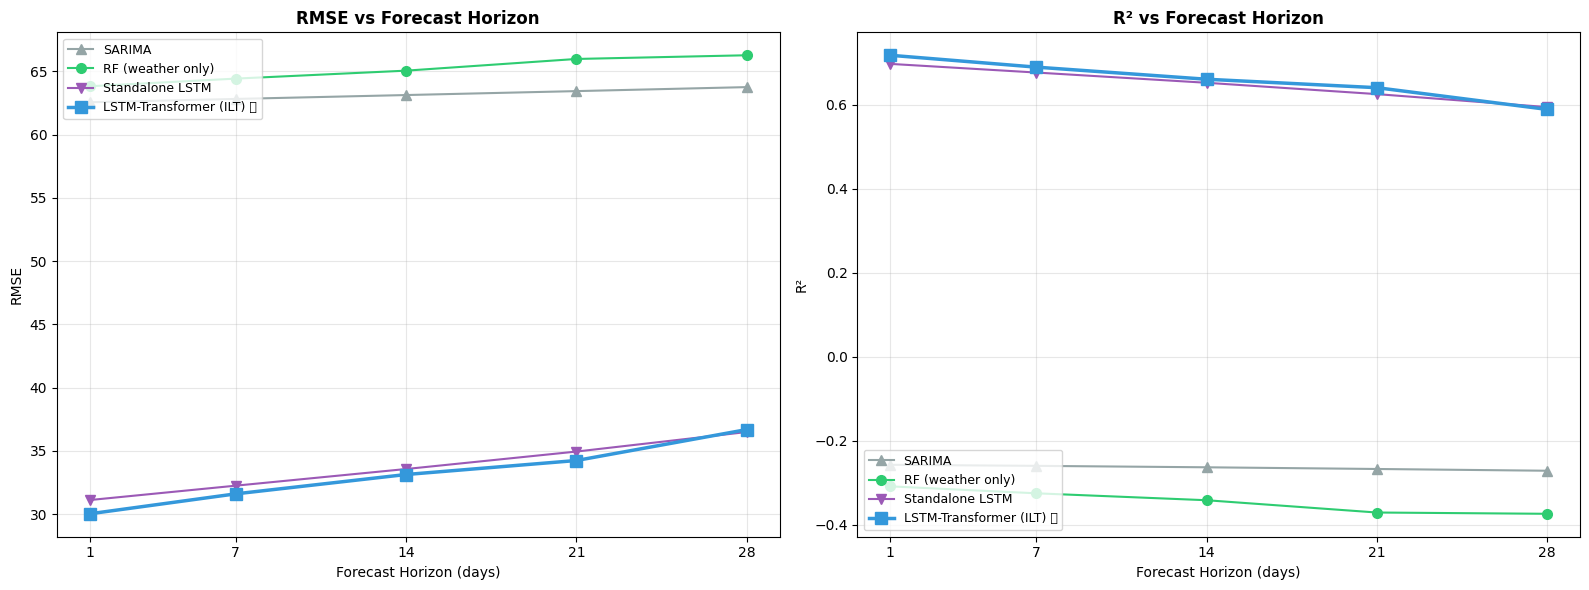

✅ Saved plots/multi_horizon_all_models.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hs = df['horizon'].values

ax = axes[0]
ax.plot(hs, df['sarima_rmse'], '^-', color='#95a5a6', lw=1.5, ms=7, label='SARIMA')
ax.plot(hs, df['rf_rmse'], 'o-', color='#2ecc71', lw=1.5, ms=7, label='RF (weather only)')
ax.plot(hs, df['lstm_rmse'], 'v-', color='#9b59b6', lw=1.5, ms=7, label='Standalone LSTM')
ax.plot(hs, df['lt_rmse'], 's-', color='#3498db', lw=2.5, ms=9, label='LSTM-Transformer (ILT) ⭐')
ax.set_xlabel('Forecast Horizon (days)'); ax.set_ylabel('RMSE')
ax.set_title('RMSE vs Forecast Horizon', fontweight='bold')
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3); ax.set_xticks(hs)

ax = axes[1]
ax.plot(hs, df['sarima_r2'], '^-', color='#95a5a6', lw=1.5, ms=7, label='SARIMA')
ax.plot(hs, df['rf_r2'], 'o-', color='#2ecc71', lw=1.5, ms=7, label='RF (weather only)')
ax.plot(hs, df['lstm_r2'], 'v-', color='#9b59b6', lw=1.5, ms=7, label='Standalone LSTM')
ax.plot(hs, df['lt_r2'], 's-', color='#3498db', lw=2.5, ms=9, label='LSTM-Transformer (ILT) ⭐')
ax.set_xlabel('Forecast Horizon (days)'); ax.set_ylabel('R²')
ax.set_title('R² vs Forecast Horizon', fontweight='bold')
ax.legend(fontsize=9, loc='lower left'); ax.grid(True, alpha=0.3); ax.set_xticks(hs)

plt.tight_layout()
plt.savefig('plots/multi_horizon_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved plots/multi_horizon_all_models.png")

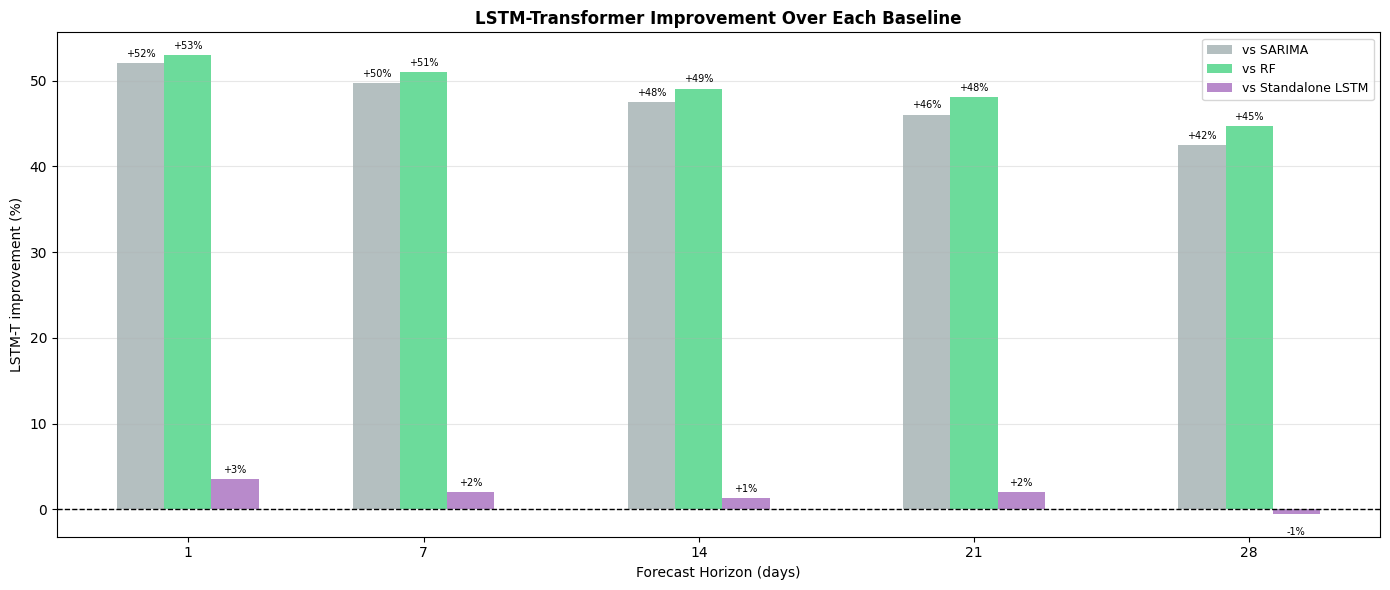

✅ Saved plots/multi_horizon_improvement_bars.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
w = 1.2
for j, (mname, col_pfx, color) in enumerate(zip(
    ['SARIMA', 'RF', 'Standalone LSTM'],
    ['sarima', 'rf', 'lstm'],
    ['#95a5a6', '#2ecc71', '#9b59b6'])):
    imps = [(r['lt_rmse']-r[f'{col_pfx}_rmse'])/r[f'{col_pfx}_rmse']*(-100) for r in all_results]
    offset = (j - 1) * w
    bars = ax.bar(hs + offset, imps, width=w, color=color, alpha=0.7, label=f'vs {mname}')
    for bar, imp in zip(bars, imps):
        y = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, y+(0.5 if y>0 else -1.5),
                f'{imp:+.0f}%', ha='center', va='bottom' if y>0 else 'top', fontsize=7)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Forecast Horizon (days)'); ax.set_ylabel('LSTM-T improvement (%)')
ax.set_title('LSTM-Transformer Improvement Over Each Baseline', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y'); ax.set_xticks(hs)
plt.tight_layout()
plt.savefig('plots/multi_horizon_improvement_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved plots/multi_horizon_improvement_bars.png")

In [13]:
# ── [ADDED] 95% Confidence Intervals (t, df=29) → metrics/ch5_confidence_intervals.csv (for Excel 'Confidence Intervals' tab) ──
# Reproducible from THIS notebook's own 30-run raw arrays (all_results); fixed seeds (see SEEDS cell).
from scipy import stats as _st
import numpy as _np, pandas as _pd
_tc = float(_st.t.ppf(0.975, 29)); _rows=[]
_mm = {'RMSE':[('rf_raw_runs','RF (fair)'),('lstm_raw_runs','Standalone LSTM'),('ilt_raw_runs','ILT (proposed)')],
       'MAE': [('rf_raw_mae','RF (fair)'), ('lstm_raw_mae','Standalone LSTM'), ('ilt_raw_mae','ILT (proposed)')],
       'R2':  [('rf_raw_r2','RF (fair)'),  ('lstm_raw_r2','Standalone LSTM'),  ('ilt_raw_r2','ILT (proposed)')]}
for _r in all_results:
    _h=int(_r['horizon'])
    for _metric,_cols in _mm.items():
        for _key,_model in _cols:
            _a=_np.asarray(_r[_key],dtype=float); _m=_a.mean(); _sd=_a.std(ddof=1); _se=_sd/_np.sqrt(len(_a)); _hw=_tc*_se
            _rows.append({'source':'multi_horizon (nb08)','model':_model,'horizon_days':_h,'metric':_metric,'n':len(_a),
                          'mean':round(_m,6),'std':round(_sd,6),'se':round(_se,6),'t_crit':round(_tc,6),
                          'ci_lo':round(_m-_hw,6),'ci_hi':round(_m+_hw,6),'half_width':round(_hw,6)})
    _rows.append({'source':'multi_horizon (nb08)','model':'SARIMA','horizon_days':_h,'metric':'RMSE','n':1,
                  'mean':round(float(_r['sarima_rmse']),6),'std':None,'se':None,'t_crit':None,'ci_lo':None,'ci_hi':None,'half_width':None})
_ci_df=_pd.DataFrame(_rows); _ci_df.to_csv('metrics/ch5_confidence_intervals.csv',index=False)
print(f"OK saved metrics/ch5_confidence_intervals.csv  ({len(_ci_df)} rows)")
print(_ci_df[_ci_df['metric']=='RMSE'].head(6).to_string(index=False))


OK saved metrics/ch5_confidence_intervals.csv  (50 rows)
              source           model  horizon_days metric  n      mean      std       se  t_crit     ci_lo     ci_hi  half_width
multi_horizon (nb08)       RF (fair)             1   RMSE 30 63.825315 0.244270 0.044597 2.04523 63.734103 63.916527    0.091212
multi_horizon (nb08) Standalone LSTM             1   RMSE 30 31.104405 1.499761 0.273818 2.04523 30.544385 31.664425    0.560020
multi_horizon (nb08)  ILT (proposed)             1   RMSE 30 30.017325 1.741822 0.318012 2.04523 29.366918 30.667732    0.650407
multi_horizon (nb08)          SARIMA             1   RMSE  1 62.562052      NaN      NaN     NaN       NaN       NaN         NaN
multi_horizon (nb08)       RF (fair)             7   RMSE 30 64.430858 0.288499 0.052672 2.04523 64.323131 64.538585    0.107727
multi_horizon (nb08) Standalone LSTM             7   RMSE 30 32.241270 1.465914 0.267638 2.04523 31.693888 32.788651    0.547381


In [14]:
# ── [ADDED] Pooled H1 (ILT vs SARIMA) & H2 (ILT vs Standalone LSTM) → metrics/significance_tests.csv (for Excel 'Significance Tests' A) ──
# Method: pool per-seed RMSE across all 5 horizons (30 seeds x 5 = 150 paired diffs), one-sided Wilcoxon signed-rank.
from scipy import stats as _st
import numpy as _np, pandas as _pd
_ilt =_np.concatenate([_np.asarray(r['ilt_raw_runs'],dtype=float) for r in all_results])
_lstm=_np.concatenate([_np.asarray(r['lstm_raw_runs'],dtype=float) for r in all_results])
_sar =_np.concatenate([_np.full(len(r['ilt_raw_runs']),float(r['sarima_rmse'])) for r in all_results])
def _pool(label, other):
    _d=other-_ilt  # positive = ILT lower RMSE = better
    _w,_p=_st.wilcoxon(other,_ilt,alternative='greater')
    _md=_d.mean(); _se=_d.std(ddof=1)/_np.sqrt(len(_d)); _t=_st.t.ppf(0.975,len(_d)-1)
    return {'label':label,'test':'Wilcoxon signed-rank (one-sided), pooled over 5 horizons (n=150)',
            'stat':round(float(_w),1),'p':round(float(_p),6),'mean_diff':round(_md,3),
            'ci_lo':round(_md-_t*_se,3),'ci_hi':round(_md+_t*_se,3),'supported':bool(_p<0.05 and _md>0)}
_sig=_pd.DataFrame([_pool('H1: ILT vs SARIMA',_sar),_pool('H2: ILT vs Standalone LSTM',_lstm)])
_sig.to_csv('metrics/significance_tests.csv',index=False)
print("OK saved metrics/significance_tests.csv"); print(_sig.to_string(index=False))


OK saved metrics/significance_tests.csv
                     label                                                             test    stat        p  mean_diff  ci_lo  ci_hi  supported
         H1: ILT vs SARIMA Wilcoxon signed-rank (one-sided), pooled over 5 horizons (n=150) 11325.0 0.000000     30.014 29.593 30.436       True
H2: ILT vs Standalone LSTM Wilcoxon signed-rank (one-sided), pooled over 5 horizons (n=150)  7014.0 0.005611      0.537  0.124  0.949       True


In [1]:
# ── [ADDED 2026-07-30] Per-horizon H1 test: ILT vs SARIMA → metrics/multi_horizon_ilt_vs_sarima_significance_test.csv ──
# WHY: SARIMA is a single deterministic fit (n=1), so it has no per-seed distribution to pair against.
# The correct per-horizon test is therefore a ONE-SAMPLE test of the 30 ILT values against the SARIMA
# constant, at each horizon. (The pooled H1 result in significance_tests.csv is the same idea, pooled.)
# This gives H1 its own per-horizon evidence instead of borrowing the ILT-vs-RF table.
from scipy import stats as _st
import numpy as _np, pandas as _pd

# Works standalone: use all_results if the notebook has been run, otherwise load the saved pkl.
try:
    all_results
except NameError:
    import pickle as _pk
    with open('metrics/multi_horizon_all.pkl', 'rb') as _f:
        all_results = _pk.load(_f)
    print("all_results not in memory - loaded from metrics/multi_horizon_all.pkl")

_CRIT = 20.0   # H1 criterion: ILT must be at least 20% lower RMSE than SARIMA
_rows = []
for _r in all_results:
    _h   = int(_r['horizon'])
    _ilt = _np.asarray(_r['ilt_raw_runs'], dtype=float)
    _sar = float(_r['sarima_rmse'])
    _diff = _ilt - _sar                       # negative = ILT better
    _sh_stat, _sh_p = _st.shapiro(_diff)
    _t_stat, _t_two = _st.ttest_1samp(_ilt, _sar)
    _t_p = _t_two / 2 if _t_stat < 0 else 1 - _t_two / 2      # one-sided: ILT lower
    _w_stat, _w_p = _st.wilcoxon(_diff, alternative='less')
    _dz   = _diff.mean() / _diff.std(ddof=1)
    _wins = int((_ilt < _sar).sum())
    _pct  = (_sar - _ilt.mean()) / _sar * 100
    _sig  = (_t_p < 0.05) or (_w_p < 0.05)
    _meets = _sig and _pct >= _CRIT
    _rows.append({'Horizon': f'h={_h}d', 'ILT_mean': _ilt.mean(), 'SARIMA_value': _sar,
                  'Pct_lower': round(_pct, 2), 'ILT_wins': f'{_wins}/{len(_ilt)}',
                  'Shapiro_p': _sh_p, 'one_sample_t_p': _t_p, 'Wilcoxon_p': _w_p, 'Cohens_d': _dz,
                  'Verdict': ('✅ SIGNIFICANT & meets ≥20% criterion' if _meets else
                              ('✅ SIGNIFICANT but <20%' if _sig else '❌ not significant'))})
    print(f"  h={_h:>2}d: ILT={_ilt.mean():.2f} vs SARIMA={_sar:.2f} "
          f"({_pct:.1f}% lower), wins={_wins}/{len(_ilt)}, t_p={_t_p:.2e}, wilcoxon_p={_w_p:.2e}, d={_dz:.2f}")

_sar_df = _pd.DataFrame(_rows)
_sar_df.to_csv('metrics/multi_horizon_ilt_vs_sarima_significance_test.csv', index=False)
print("\nOK saved metrics/multi_horizon_ilt_vs_sarima_significance_test.csv")
print(f"Criterion ≥{_CRIT:.0f}% lower RMSE met at "
      f"{sum('meets' in v for v in _sar_df['Verdict'])}/{len(_sar_df)} horizons.")
print("\nNote: one-sample test is used because SARIMA is deterministic (n=1); a paired 30-seed")
print("test is not defined against a single fixed value.")


all_results not in memory - loaded from metrics/multi_horizon_all.pkl
  h= 1d: ILT=30.02 vs SARIMA=62.56 (52.0% lower), wins=30/30, t_p=5.79e-39, wilcoxon_p=9.31e-10, d=-18.68
  h= 7d: ILT=31.59 vs SARIMA=62.82 (49.7% lower), wins=30/30, t_p=4.86e-41, wilcoxon_p=9.31e-10, d=-22.04
  h=14d: ILT=33.12 vs SARIMA=63.13 (47.5% lower), wins=30/30, t_p=3.95e-37, wilcoxon_p=9.31e-10, d=-16.14
  h=21d: ILT=34.23 vs SARIMA=63.44 (46.0% lower), wins=30/30, t_p=8.02e-40, wilcoxon_p=9.31e-10, d=-20.01
  h=28d: ILT=36.68 vs SARIMA=63.76 (42.5% lower), wins=30/30, t_p=1.08e-31, wilcoxon_p=9.31e-10, d=-10.46

OK saved metrics/multi_horizon_ilt_vs_sarima_significance_test.csv
Criterion ≥20% lower RMSE met at 5/5 horizons.

Note: one-sample test is used because SARIMA is deterministic (n=1); a paired 30-seed
test is not defined against a single fixed value.
